# Tikhonov regularization, the conjugate gradient method and the L-curve
Consider the problem from lab 3. Another approach that can avoid the effects of semi-convergence is to solve instead of the least-squares problem
$$ \min_{\alpha} \frac{1}{2} \| A \alpha - g \|^2 $$
the regularized problem
$$ \min_{\alpha} \frac{1}{2} \| A \alpha - g \|^2 + \frac{\lambda}{2} \| \alpha \|^2 $$
with a regularization parameter $\lambda > 0$. It turns out that for a suitably chosen parameter $\lambda$ (depending on the noise level and the problem) the exact solution of the regularized problem (called [Tikhonov regularization](https://en.wikipedia.org/wiki/Tikhonov_regularization)) is a more accurate reconstruction than a solution of the unregularized problem (though there are typically better regularization alternatives). The optimality condition now reads $0 = A^t (A \alpha - g) + \lambda \alpha$. For the reconstruction problem described in lab 3, find a regularized solution for some choice of $\lambda$ using the conjugate gradient method and plot the relative error. Then, try to find a good choice of the parameter $\lambda$ with the L-curve method. For the L-curve you should not do a full reconstruction for each $\lambda$, but only a few iterations to save time. Compare with the Landweber solution. 

Make sure to keep $\lambda$ in a reasonable range, otherwise ``odl.solvers.conjugate_gradient`` divides by zero once the residual underflows. This problem typically kicks in with very large regularization parameters, in this case $\lambda \sim 10^3$.

# RUN THIS ONCE

In [1]:
!nvidia-smi
!rm -rf InverseProblems-Labs
!git clone https://github.com/AhouLucas/InverseProblems-Labs.git
%cd InverseProblems-Labs
!uv pip install --system odl==1.0.0 astra-toolbox

Tue Sep 29 08:13:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# THEN RESTART KERNEL AND RUN FROM HERE

In [1]:
%cd /content/InverseProblems-Labs

/content/InverseProblems-Labs


In [2]:
import odl
import numpy as np
import matplotlib.pyplot as plt

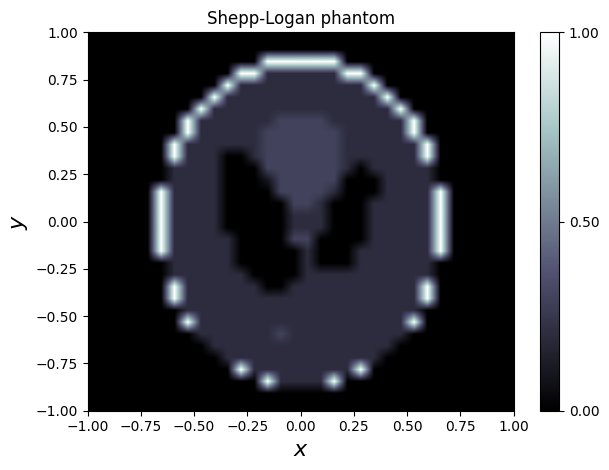

<Figure size 640x480 with 0 Axes>

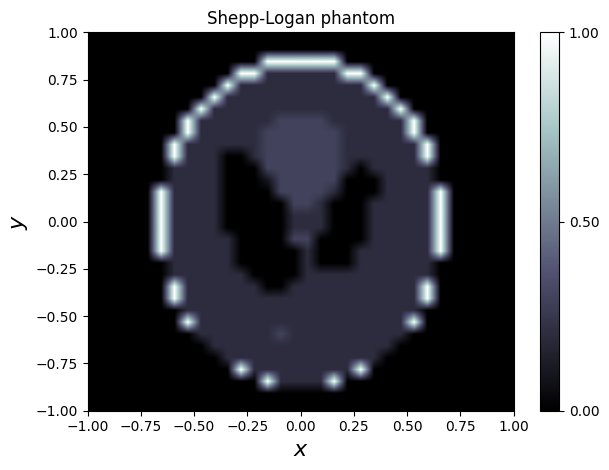

In [3]:
space = odl.uniform_discr((-1, -1, -1), (1, 1, 1), (32, 32, 32), dtype='float32')

shepp_logan = odl.phantom.transmission.shepp_logan(space, modified=True)
shepp_logan.show(title='Shepp-Logan phantom')

Noise level (L2 norm): 0.0687


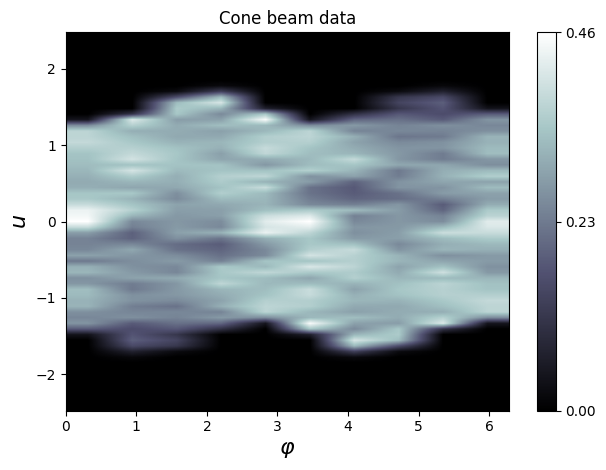

<Figure size 640x480 with 0 Axes>

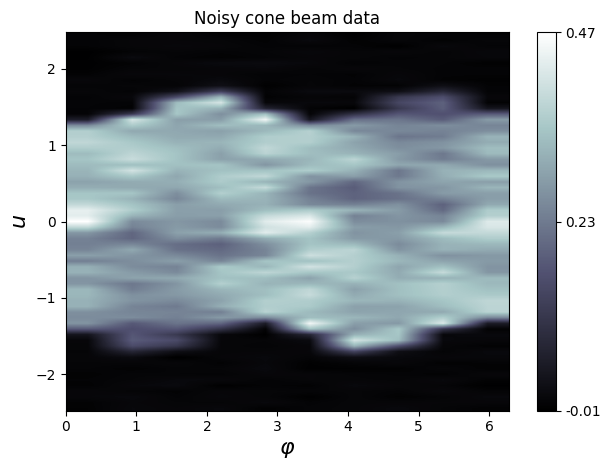

<Figure size 640x480 with 0 Axes>

In [4]:
cone_beam_geo = odl.applications.tomo.cone_beam_geometry(space, src_radius=2.0, det_radius=1.5, num_angles=10)
ray_transform = odl.applications.tomo.RayTransform(space, cone_beam_geo, impl='astra_cuda')
ray_transform_elements = ray_transform(shepp_logan)
noisy_elements = ray_transform_elements + odl.phantom.white_noise(ray_transform.range, stddev=0.005)

# Compute noise level
error = noisy_elements - ray_transform_elements
noise_level = error.norm()
print(f"Noise level (L2 norm): {noise_level:.4f}")

fig_ray_transform_elements = ray_transform(shepp_logan).show(title='Cone beam data')
fig_noisy_elements = noisy_elements.show(title='Noisy cone beam data')

In [36]:
def conjugate_gradient(A, y, lam, max_iter=100):
    logs = {
        "residual_norms": [],
    }

    def callback(xk):
        residual = y - A(xk)
        residual_norm = residual.norm()
        logs["residual_norms"].append(residual_norm)

    x = A.domain.zero()
    odl.solvers.conjugate_gradient((A.adjoint * A) + lam * odl.IdentityOperator(A.domain), x, A.adjoint(y), niter=max_iter, callback=callback)

    return x, logs



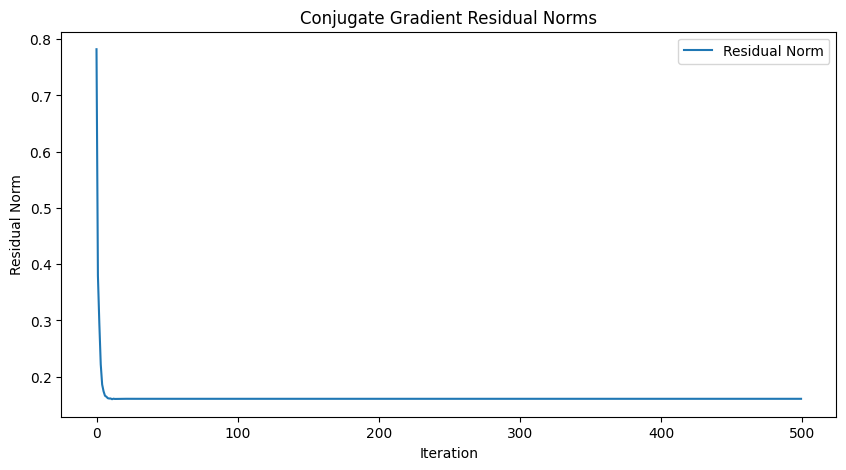

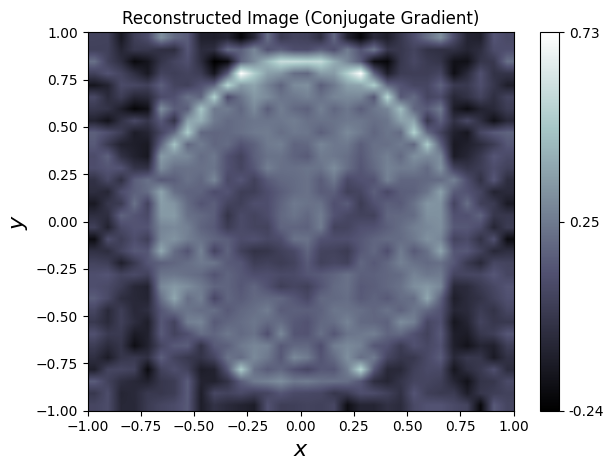

<Figure size 640x480 with 0 Axes>

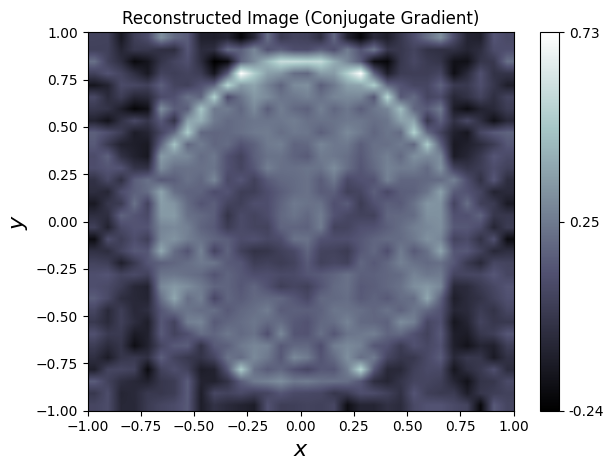

In [42]:
x, logs = conjugate_gradient(ray_transform, noisy_elements, lam=1, max_iter=500)

# plot the logs
plt.figure(figsize=(10, 5))
plt.plot(logs["residual_norms"], label='Residual Norm')
plt.xlabel('Iteration')
plt.ylabel('Residual Norm')
plt.title('Conjugate Gradient Residual Norms')
plt.legend()

x.show(title='Reconstructed Image (Conjugate Gradient)')

Text(0.5, 1.0, 'L-curve')

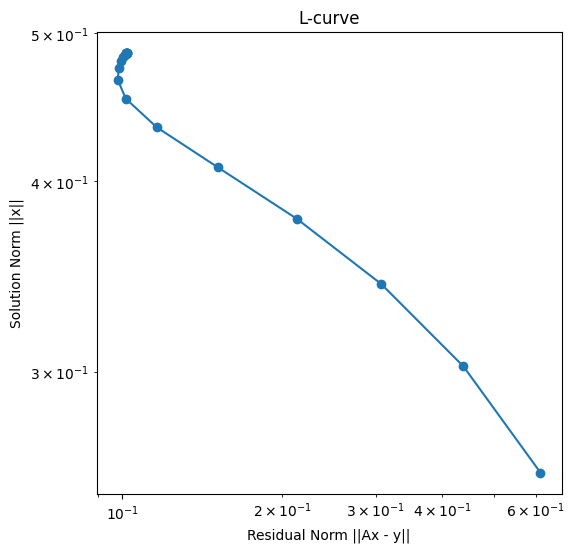

In [46]:
# Compute and plot L-curve
lambda_values = np.logspace(-4, 1, 20)
x_norms = []
residual_norms = []
for lamb in lambda_values:
    x, logs = conjugate_gradient(ray_transform, noisy_elements, lam=float(lamb), max_iter=10)
    x_norms.append(x.norm())
    residual_norms.append(logs["residual_norms"][-1])

plt.figure(figsize=(6, 6))
plt.loglog(residual_norms, x_norms, marker='o')
plt.xlabel('Residual Norm ||Ax - y||')
plt.ylabel('Solution Norm ||x||')
plt.title('L-curve')